# PINN Flow over NACA 23018 at Zero Angle of Attack

A physics-informed neural-network model for steady incompressible flow at Reynolds number 100.


  Preparing metadata (setup.py) ... done
  Created wheel for pyDOE: filename=pyDOE-0.3.8-py3-none-any.whl size=18170 sha256=26a83aa626b7b8df60dd1b0a3ef01e96b56cdaa26098b73d0569d607fe0111a1
  Stored in directory: /root/.cache/pip/wheels/96/b9/5d/1138ea8c8f212bce6e97ae58847b7cc323145b3277f2129e2b
Successfully built pyDOE
True
1
cuda
xy_col shape: (46499, 2)


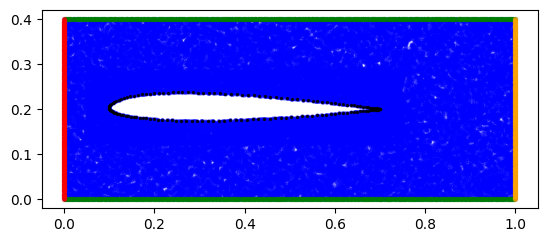

 It: 100 Loss: 1.17094e+01 BC: 1.169e-01 outlet: 4.758e-04 pde: 2.078e-02
 It: 200 Loss: 9.29155e+00 BC: 9.255e-02 outlet: 1.715e-04 pde: 3.638e-02
 It: 300 Loss: 4.56973e+00 BC: 4.513e-02 outlet: 1.033e-03 pde: 5.580e-02
 It: 400 Loss: 4.07032e+00 BC: 4.002e-02 outlet: 9.097e-04 pde: 6.712e-02
 It: 500 Loss: 3.53014e+00 BC: 3.319e-02 outlet: 4.755e-04 pde: 2.103e-01
 It: 600 Loss: 3.22024e+00 BC: 2.941e-02 outlet: 7.203e-04 pde: 2.789e-01
 It: 700 Loss: 2.91069e+00 BC: 2.591e-02 outlet: 1.033e-03 pde: 3.188e-01
 It: 800 Loss: 2.61995e+00 BC: 2.247e-02 outlet: 1.218e-03 pde: 3.722e-01
 It: 900 Loss: 2.38558e+00 BC: 1.946e-02 outlet: 1.141e-03 pde: 4.388e-01
 It: 1000 Loss: 2.18913e+00 BC: 1.703e-02 outlet: 1.046e-03 pde: 4.855e-01
 It: 1100 Loss: 1.97349e+00 BC: 1.436e-02 outlet: 1.002e-03 pde: 5.362e-01
 It: 1200 Loss: 1.82200e+00 BC: 1.286e-02 outlet: 9.164e-04 pde: 5.354e-01
 It: 1300 Loss: 1.72879e+00 BC: 1.194e-02 outlet: 9.239e-04 pde: 5.343e-01
 It: 1400 Loss: 1.63913e+00 BC: 1.

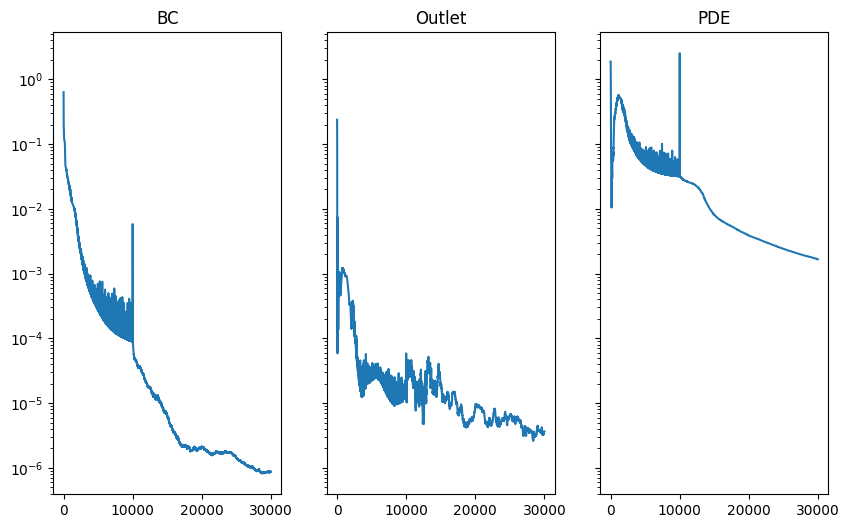

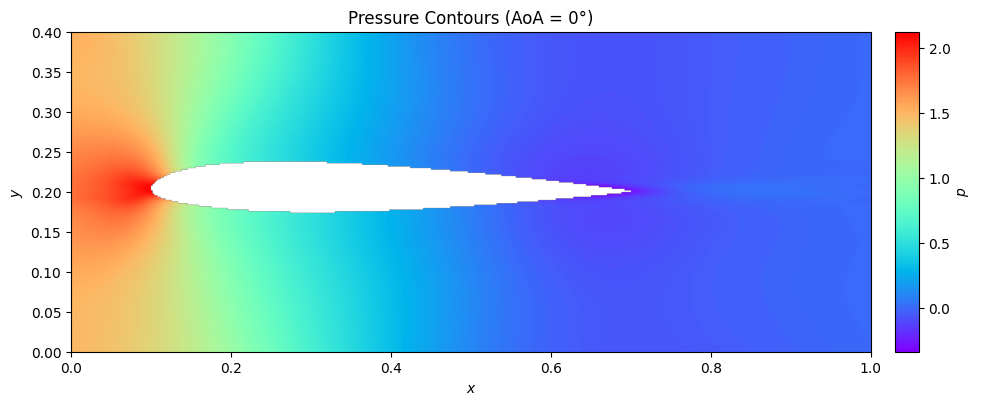

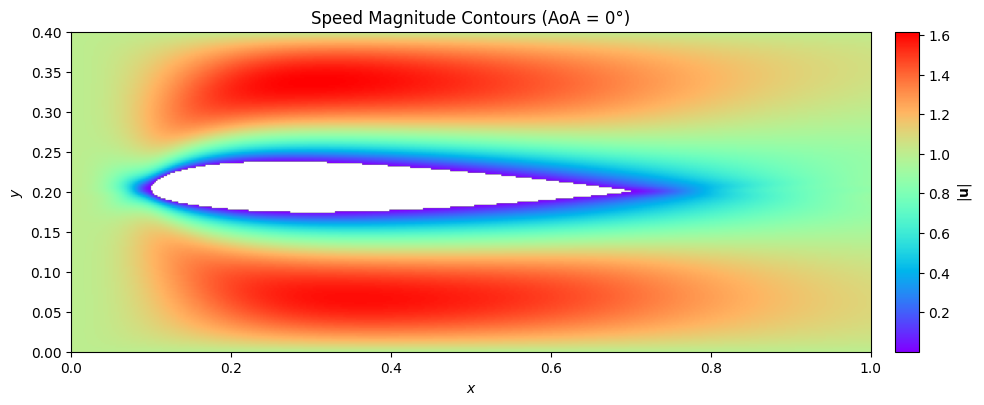

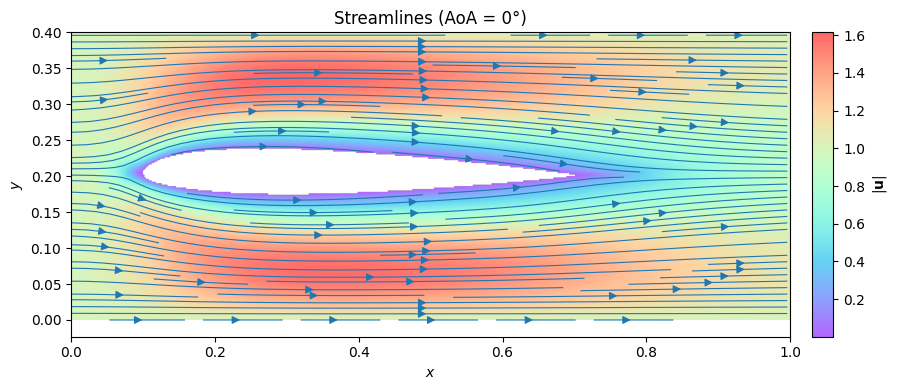

In [ ]:
# ===================== PINN =====================

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.autograd import grad
from mpl_toolkits.axes_grid1 import make_axes_locatable
import time


# ===================== Device & Seeds =====================
# Select GPU if available, otherwise use CPU
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

# Fix random seeds for reproducibility (same initialization + sampling every run)
torch.manual_seed(1234)
np.random.seed(1234)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(1234)

# Quick diagnostics: do we have CUDA? how many GPUs? which device is used?
print(torch.cuda.is_available())
print(torch.cuda.device_count())
print(device)

# --------------------- Domain (2D channel box) ---------------------
# Computational domain: x in [0,1], y in [0,0.4]
x_min = 0.0
x_max = 1.0
y_min = 0.0
y_max = 0.4

# --------------------- Flow Params ---------------------
# Free-stream/inlet velocity magnitude
U_inf = 1.0

# Upper/lower bounds of the domain (used for sampling and input normalization)
ub = np.array([x_max, y_max], dtype=np.float32)
lb = np.array([x_min, y_min], dtype=np.float32)

# Training point counts
N_b = 200    # number of points on inlet and outlet lines (each)
N_w = 400    # number of points on top and bottom boundaries (each)
N_c = 40000  # number of interior collocation points for PDE residual
N_r = 10000  # number of extra collocation points near the airfoil (refinement region)

# --------------------- Utilities ---------------------
def points_in_polygon(xy_pts, poly_xy):
    """
    Ray-casting point-in-polygon test.

    Parameters
    ----------
    xy_pts : (M,2) array
        Query points to test.
    poly_xy : (N,2) array
        Polygon vertices (airfoil surface points). Can be open or closed.

    Returns
    -------
    inside : (M,) boolean array
        True for points inside the polygon.
    """
    poly = np.array(poly_xy, dtype=np.float64)

    # Ensure polygon is closed by repeating the first vertex at the end (if needed)
    if not np.allclose(poly[0], poly[-1]):
        poly = np.vstack([poly, poly[0]])

    # Query points
    x, y = xy_pts[:, 0], xy_pts[:, 1]

    # Polygon edges: (x1,y1) -> (x2,y2)
    x1, y1 = poly[:-1, 0], poly[:-1, 1]
    x2, y2 = poly[1:, 0], poly[1:, 1]

    inside = np.zeros(x.shape[0], dtype=bool)

    # For each polygon edge, toggle "inside" state if a horizontal ray from the point crosses the edge
    for i in range(len(x1)):
        # Does the horizontal line at y cross the vertical span of the edge?
        cond = ((y1[i] > y) != (y2[i] > y))

        # x-coordinate where the edge intersects that horizontal line
        xin = (x2[i] - x1[i]) * (y - y1[i]) / ((y2[i] - y1[i]) + 1e-15) + x1[i]

        # A crossing happens if (1) y is within the edge span and (2) the point is left of intersection
        hit = cond & (x < xin)

        # XOR toggle: odd number of crossings => inside, even => outside
        inside ^= hit

    return inside


# --------------------- Data Preparation ---------------------
def getData():
    # --------- Airfoil surface (from file) ---------
    # Data.txt should contain airfoil coordinates (x,y) in 2 columns
    af = np.loadtxt("/content/Data.txt")
    x_af = af[:, 0:1]  # keep as column vector (N,1)
    y_af = af[:, 1:2]  # keep as column vector (N,1)

    # Place the airfoil inside the channel box by scaling and shifting
    # - x: scale to chord ~0.6 and shift near x=0.4
    # - y: scale and shift to fit within y in [0, 0.4]
    x_af = 0.4 + 0.6 * (x_af - 0.5)   # chord ~ 0.6 inside [0,1]
    y_af = 0.2 + 0.35 * y_af          # fit vertically inside [0,0.4]

    # Airfoil boundary points (N,2)
    airfoil_x = x_af.reshape(-1, 1)
    airfoil_y = y_af.reshape(-1, 1)
    airfoil_xy = np.concatenate([airfoil_x, airfoil_y], axis=1).astype(np.float32)

    # No-slip boundary condition on the airfoil: u=v=0 on the surface points
    airfoil_uv = np.zeros((airfoil_xy.shape[0], 2), dtype=np.float32)

    # --------- Inlet / Outlet / Top / Bottom sampling ---------
    # Free-stream direction: along +x
    Ux, Uy = U_inf, 0.0

    # Inlet boundary (x = 0): sample y with Latin Hypercube Sampling (LHS)
    inlet_y = y_min + (y_max - y_min) * lhs(1, N_b)
    inlet_x = np.zeros((N_b, 1))
    inlet_xy = np.hstack([inlet_x, inlet_y]).astype(np.float32)

    # Inlet velocity BC: u=U_inf, v=0 at inlet points
    inlet_uv = np.hstack([Ux*np.ones((N_b,1)), Uy*np.ones((N_b,1))]).astype(np.float32)

    # Outlet boundary (x = 1): sample y points for pressure/gauge condition
    outlet_y = y_min + (y_max - y_min) * lhs(1, N_b)
    outlet_x = x_max * np.ones((N_b, 1))
    xy_outlet = np.hstack([outlet_x, outlet_y]).astype(np.float32)

    # Top boundary (y = y_max): sample x with LHS
    upwall_x = x_min + (x_max - x_min) * lhs(1, N_w)
    upwall_y = y_max * np.ones((N_w, 1))
    upwall_xy = np.hstack([upwall_x, upwall_y]).astype(np.float32)

    # Bottom boundary (y = y_min): sample x with LHS
    dnwall_x = x_min + (x_max - x_min) * lhs(1, N_w)
    dnwall_y = y_min * np.ones((N_w, 1))
    dnwall_xy = np.hstack([dnwall_x, dnwall_y]).astype(np.float32)

    # "Far-field" style BC on top/bottom: set velocity to (U_inf, 0)
    # (If these were physical solid walls, you would typically set (0,0) no-slip instead.)
    upwall_uv = np.hstack([Ux*np.ones((N_w, 1)), Uy*np.ones((N_w, 1))]).astype(np.float32)
    dnwall_uv = np.hstack([Ux*np.ones((N_w, 1)), Uy*np.ones((N_w, 1))]).astype(np.float32)

    # --------- Merge all velocity-BC points ---------
    # Combine inlet + top + bottom + airfoil surface into one BC set
    xy_bnd = np.concatenate([inlet_xy, upwall_xy, dnwall_xy, airfoil_xy], axis=0).astype(np.float32)
    uv_bnd = np.concatenate([inlet_uv, upwall_uv, dnwall_uv, airfoil_uv], axis=0).astype(np.float32)

    # --------- Collocation points for PDE residual ---------
    # Uniform-ish sampling in the full domain using LHS
    xy_col = lb + (ub - lb) * lhs(2, N_c)

    # Refinement region: add extra collocation points near the airfoil bounding box (+padding)
    pad = 0.05
    refine_lb = np.array([airfoil_x.min() - pad, airfoil_y.min() - pad])
    refine_ub = np.array([airfoil_x.max() + pad, airfoil_y.max() + pad])
    xy_col_refine = refine_lb + (refine_ub - refine_lb) * lhs(2, N_r)

    # Merge base + refined collocation points
    xy_col = np.concatenate([xy_col, xy_col_refine], axis=0)

    # Remove collocation points that fall inside the airfoil polygon
    # (PDE is enforced only in the fluid region, not inside the solid body.)
    inside = points_in_polygon(xy_col, airfoil_xy)
    xy_col = xy_col[~inside].reshape(-1, 2).astype(np.float32)

    # Optionally include boundary + outlet points in the training cloud
    # (Some PINN setups do this to stabilize training.)
    xy_col = np.concatenate((xy_col, xy_bnd, xy_outlet), axis=0).astype(np.float32)

    print("xy_col shape:", xy_col.shape)

    # --------- Quick scatter plot (sanity check) ---------
    fig, ax = plt.subplots()
    ax.set_aspect('equal')

    # All training points (collocation + BC + outlet)
    ax.scatter(xy_col[:, 0], xy_col[:, 1], marker='o', alpha=0.4, s=5, c='blue')

    # Top/bottom boundaries
    ax.scatter(upwall_xy[:, 0], upwall_xy[:, 1], marker='o', alpha=0.5, s=8, c='green')
    ax.scatter(dnwall_xy[:, 0], dnwall_xy[:, 1], marker='o', alpha=0.5, s=8, c='green')

    # Outlet and inlet
    ax.scatter(xy_outlet[:, 0], xy_outlet[:, 1], marker='o', alpha=0.5, s=8, c='orange')
    ax.scatter(inlet_xy[:, 0], inlet_xy[:, 1], marker='o', alpha=0.5, s=8, c='red')

    # Airfoil surface points
    ax.scatter(airfoil_xy[:, 0], airfoil_xy[:, 1], marker='.', alpha=0.8, s=8, c='black')
    plt.show()

    # --------- Convert to torch tensors and move to device ---------
    xy_bnd_t    = torch.tensor(xy_bnd,    dtype=torch.float32).to(device)  # BC coordinates
    uv_bnd_t    = torch.tensor(uv_bnd,    dtype=torch.float32).to(device)  # BC target velocities
    xy_outlet_t = torch.tensor(xy_outlet, dtype=torch.float32).to(device)  # outlet coordinates
    xy_col_t    = torch.tensor(xy_col,    dtype=torch.float32).to(device)  # PDE collocation coordinates

    # Return airfoil_xy in numpy format for masking/plotting later
    return xy_col_t, xy_bnd_t, uv_bnd_t, xy_outlet_t, airfoil_xy


# --------------------- Plot Loss ---------------------
def plotLoss(losses_dict, path, info=["I.C.", "B.C.", "P.D.E."]):
    """
    Plot loss histories (log-scale) and save to disk.

    losses_dict should contain keys: "bc", "outlet", "pde"
    info controls subplot titles and which keys to access (lower-cased).
    """
    fig, axes = plt.subplots(1, 3, sharex=True, sharey=True, figsize=(10, 6))
    for i, j in zip(range(3), info):
        y = np.asarray(losses_dict[j.lower()], dtype=float)

        # Avoid invalid values when using log scale
        y = np.where(y <= 0, 1e-16, y)

        axes[i].plot(y)
        axes[i].set_title(j)

    axes[0].set_yscale("log")
    plt.show()
    fig.savefig(path, dpi=300)


# --------------------- NN utils ---------------------
def weights_init(m):
    """
    Xavier initialization for linear layers (good default for tanh networks).
    """
    if isinstance(m, nn.Linear):
        torch.nn.init.xavier_uniform_(m.weight.data)
        torch.nn.init.zeros_(m.bias.data)


class layer(nn.Module):
    """
    A single fully-connected layer + optional activation.
    """
    def __init__(self, n_in, n_out, activation):
        super().__init__()
        self.layer = nn.Linear(n_in, n_out)
        self.activation = activation

    def forward(self, x):
        x = self.layer(x)
        if self.activation:
            x = self.activation(x)
        return x


class DNN(nn.Module):
    """
    Fully-connected neural network used by the PINN.

    Input:  (x, y)
    Output: [u, v, p, sigma_xx, sigma_xy, sigma_yy]
    """
    def __init__(self, dim_in, dim_out, n_layer, n_node, ub, lb, activation=nn.Tanh()):
        super().__init__()

        # Build network as a list of layers
        self.net = nn.ModuleList()
        self.net.append(layer(dim_in, n_node, activation))  # input layer
        for _ in range(n_layer):
            self.net.append(layer(n_node, n_node, activation))  # hidden layers
        self.net.append(layer(n_node, dim_out, activation=None))  # output layer (linear)

        # Store bounds as tensors for input normalization
        self.ub = torch.tensor(ub, dtype=torch.float32).to(device)
        self.lb = torch.tensor(lb, dtype=torch.float32).to(device)

        # Initialize parameters
        self.net.apply(weights_init)

    def forward(self, x):
        # Normalize inputs to improve training stability
        x = (x - self.lb) / (self.ub - self.lb)

        out = x
        for layer_ in self.net:
            out = layer_(out)
        return out


# --------------------- PINN ---------------------
class PINN:
    """
    Physics-Informed Neural Network for 2D steady incompressible flow.

    The network predicts:
      u, v (velocity components)
      p     (pressure)
      sigma_xx, sigma_xy, sigma_yy (stress components)

    PDE is imposed in first-order stress form to avoid second derivatives of u,v.
    """

    Re = 100  # Reynolds number for this project

    def __init__(self) -> None:
        # Network: input (x,y) -> output 6 fields
        self.net = DNN(dim_in=2, dim_out=6, n_layer=4, n_node=50, ub=ub, lb=lb).to(device)

        # LBFGS optimizer (often used as a second stage in PINNs for fine convergence)
        self.lbfgs = torch.optim.LBFGS(
            self.net.parameters(),
            lr=1.0,
            max_iter=20000,
            max_eval=20000,
            tolerance_grad=1e-5,
            tolerance_change=1.0 * np.finfo(float).eps,
            history_size=50,
            line_search_fn="strong_wolfe",
        )

        # Adam optimizer (first stage, robust early training)
        self.adam = torch.optim.Adam(self.net.parameters(), lr=5e-4)

        # Store loss histories for plotting
        self.losses = {"bc": [], "outlet": [], "pde": []}
        self.iter = 0

        # Chunk size for PDE residual evaluation (prevents GPU OOM)
        self.pde_chunk = 8192

    def predict(self, xy):
        """
        Forward pass returning each predicted field as (N,1) tensors.
        """
        out = self.net(xy)
        u = out[:, 0:1]
        v = out[:, 1:2]
        p = out[:, 2:3]
        sig_xx = out[:, 3:4]
        sig_xy = out[:, 4:5]
        sig_yy = out[:, 5:6]
        return u, v, p, sig_xx, sig_xy, sig_yy

    def bc_loss(self, xy, uv_bnd):
        """
        Velocity boundary condition loss: enforce u,v on inlet/top/bottom/airfoil.
        """
        u, v = self.predict(xy)[0:2]
        mse_bc = torch.mean((u - uv_bnd[:, 0:1])**2) + torch.mean((v - uv_bnd[:, 1:2])**2)
        return mse_bc

    def outlet_loss(self, xy):
        """
        Outlet gauge pressure loss: enforce p ~ 0 on the outlet line.
        """
        p = self.net(xy)[:, 2:3]
        return torch.mean(p**2)

    def _pde_mse_chunk(self, xy):
        """
        PDE residual MSE for one chunk of collocation points.

        Uses autograd to compute first derivatives w.r.t. x and y.
        """
        xy = xy.clone().requires_grad_(True)

        u, v, p, sig_xx, sig_xy, sig_yy = self.predict(xy)

        # Velocity gradients
        u_out = grad(u.sum(), xy, create_graph=True, retain_graph=True)[0]
        v_out = grad(v.sum(), xy, create_graph=True, retain_graph=True)[0]
        u_x, u_y = u_out[:, 0:1], u_out[:, 1:2]
        v_x, v_y = v_out[:, 0:1], v_out[:, 1:2]

        # Stress gradients
        sig_xx_out = grad(sig_xx.sum(), xy, create_graph=True, retain_graph=True)[0]
        sig_xy_out = grad(sig_xy.sum(), xy, create_graph=True, retain_graph=True)[0]
        sig_yy_out = grad(sig_yy.sum(), xy, create_graph=True, retain_graph=True)[0]
        sig_xx_x = sig_xx_out[:, 0:1]
        sig_xy_x = sig_xy_out[:, 0:1]
        sig_xy_y = sig_xy_out[:, 1:2]
        sig_yy_y = sig_yy_out[:, 1:2]

        # Continuity (incompressibility): du/dx + dv/dy = 0
        f0 = u_x + v_y

        # Momentum equations in first-order stress form:
        # (u·∇)u - ∂σxx/∂x - ∂σxy/∂y = 0
        # (u·∇)v - ∂σxy/∂x - ∂σyy/∂y = 0
        f1 = (u * u_x + v * u_y) - sig_xx_x - sig_xy_y
        f2 = (u * v_x + v * v_y) - sig_xy_x - sig_yy_y

        # Constitutive (Newtonian) stress relations in nondimensional form:
        f3 = -p + (2 / self.Re) * u_x - sig_xx
        f4 = -p + (2 / self.Re) * v_y - sig_yy
        f5 = (1 / self.Re) * (u_y + v_x) - sig_xy

        # Mean-squared error of all residuals
        mse = sum(torch.mean(fi**2) for fi in [f0, f1, f2, f3, f4, f5])
        return mse

    def pde_loss(self, xy):
        """
        Compute PDE loss over all collocation points using chunking to save memory.
        """
        m = xy.shape[0]
        if m <= self.pde_chunk:
            return self._pde_mse_chunk(xy)

        total = 0.0
        count = 0
        for i in range(0, m, self.pde_chunk):
            sub = xy[i:i+self.pde_chunk]
            mse_sub = self._pde_mse_chunk(sub)
            bs = sub.shape[0]
            total = total + mse_sub * bs
            count += bs
        return total / count

    def closure(self, xy_bnd, uv_bnd, xy_outlet, xy_col):
        """
        Closure function used by both Adam and LBFGS.
        It:
          1) zeros gradients
          2) computes BC, outlet, PDE losses
          3) combines them into total loss
          4) backpropagates (loss.backward())
        """
        self.lbfgs.zero_grad()
        self.adam.zero_grad()

        mse_bc = self.bc_loss(xy_bnd, uv_bnd)
        mse_outlet = self.outlet_loss(xy_outlet)
        mse_pde = self.pde_loss(xy_col)

        # Heavier weight on BC to strongly enforce boundary conditions
        loss = 100 * mse_bc + mse_outlet + mse_pde
        loss.backward()

        # Store loss components for plotting
        self.losses["bc"].append(mse_bc.detach().cpu().item())
        self.losses["outlet"].append(mse_outlet.detach().cpu().item())
        self.losses["pde"].append(mse_pde.detach().cpu().item())

        self.iter += 1

        # Print training progress on the same console line
        print(
            f"\r It: {self.iter} Loss: {loss.item():.5e} BC: {mse_bc.item():.3e} outlet: {mse_outlet.item():.3e} pde: {mse_pde.item():.3e}",
            end="",
        )
        if self.iter % 100 == 0:
            print("")

        return loss


# --------------------- Train & Save (AoA = 0°) ---------------------
if __name__ == "__main__":

    # Generate training data (collocation + BC + outlet + airfoil surface)
    xy_col, xy_bnd, uv_bnd, xy_outlet, airfoil_xy_np = getData()

    pinn = PINN()
    start_time = time.time()

    # --------- Adam phase ---------
    # Fast and stable early optimization
    for i in range(10000):
        pinn.closure(xy_bnd, uv_bnd, xy_outlet, xy_col)
        pinn.adam.step()

    # --------- LBFGS phase ---------
    # Strong second-stage optimizer to refine the solution
    pinn.lbfgs.step(lambda: pinn.closure(xy_bnd, uv_bnd, xy_outlet, xy_col))

    # Timing
    print("\n--- %s seconds ---" % (time.time() - start_time))
    print(f'-- {(time.time() - start_time)/60} mins --')

    # Save trained network weights and loss curves
    torch.save(pinn.net.state_dict(), "/content/Param_alpha0.pt")
    plotLoss(pinn.losses, "/content/LossCurve_alpha0.png", ["BC", "Outlet", "PDE"])

    # Free training tensors and model to release GPU memory
    del xy_col, xy_bnd, uv_bnd, xy_outlet
    del pinn
    torch.cuda.empty_cache()

    # --------------------- Post-processing ---------------------
    # Switch to CPU for visualization (avoids GPU memory usage)
    device = torch.device("cpu")

    pinn = PINN()
    pinn.net.load_state_dict(torch.load("/content/Param_alpha0.pt", map_location=device))
    pinn.net.to(device)

    # Create a uniform grid over the domain for plotting
    dx = 0.002
    dy = 0.002
    x = np.arange(x_min, x_max, dx)
    y = np.arange(y_min, y_max, dy)
    X, Y = np.meshgrid(x, y)

    xg = X.reshape(-1, 1)
    yg = Y.reshape(-1, 1)

    # Mask grid points inside the airfoil polygon (we don't plot values inside the solid body)
    xy_grid = np.concatenate([xg, yg], axis=1)
    inside_grid = points_in_polygon(xy_grid, airfoil_xy_np)
    airfoil_mask = ~inside_grid  # True in fluid region, False inside airfoil

    # Evaluate PINN predictions on the grid
    xy = torch.tensor(xy_grid, dtype=torch.float32).to(device)

    with torch.no_grad():
        u, v, p, sig_xx, sig_xy, sig_yy = pinn.predict(xy)

        # Reshape back to 2D grid
        u = u.cpu().numpy().reshape(Y.shape)
        v = v.cpu().numpy().reshape(Y.shape)
        p = p.cpu().numpy().reshape(Y.shape)

        # Apply mask: set inside-airfoil values to NaN (not drawn)
        u = np.where(airfoil_mask.reshape(Y.shape), u, np.nan)
        v = np.where(airfoil_mask.reshape(Y.shape), v, np.nan)
        p = np.where(airfoil_mask.reshape(Y.shape), p, np.nan)

        # Speed magnitude for plotting
        speed = np.sqrt(u**2 + v**2)

    # --------- 1) Pressure contours ---------
    fig1, ax1 = plt.subplots(1, 1, figsize=(10, 4))
    im1 = ax1.imshow(
        p, cmap="rainbow", extent=[x_min, x_max, y_min, y_max], origin="lower"
    )
    divider = make_axes_locatable(ax1)
    cax1 = divider.append_axes("right", size="3%", pad="3%")
    fig1.colorbar(im1, cax=cax1, label="$p$")
    ax1.set_title("Pressure Contours (AoA = 0°)")
    ax1.set_xlabel("$x$")
    ax1.set_ylabel("$y$")
    ax1.set_aspect("equal")
    fig1.tight_layout()
    fig1.savefig("/content/pressure_alpha0.png", dpi=500)

    # --------- 2) Speed magnitude contours ---------
    fig2, ax2 = plt.subplots(1, 1, figsize=(10, 4))
    im2 = ax2.imshow(
        speed, cmap="rainbow", extent=[x_min, x_max, y_min, y_max], origin="lower"
    )
    divider = make_axes_locatable(ax2)
    cax2 = divider.append_axes("right", size="3%", pad="3%")
    fig2.colorbar(im2, cax=cax2, label="$|\\mathbf{u}|$")
    ax2.set_title("Speed Magnitude Contours (AoA = 0°)")
    ax2.set_xlabel("$x$")
    ax2.set_ylabel("$y$")
    ax2.set_aspect("equal")
    fig2.tight_layout()
    fig2.savefig("/content/speed_alpha0.png", dpi=500)

    # --------- 3) Streamlines ---------
    fig3, ax3 = plt.subplots(1, 1, figsize=(10, 4))
    im3 = ax3.imshow(
        speed, cmap="rainbow", extent=[x_min, x_max, y_min, y_max], origin="lower", alpha=0.6
    )

    # Subsample the grid for streamplot to reduce clutter and computation
    step = 2
    X_sub = X[::step, ::step]
    Y_sub = Y[::step, ::step]
    u_sub = u[::step, ::step]
    v_sub = v[::step, ::step]

    try:
        ax3.streamplot(
            X_sub, Y_sub, u_sub, v_sub, density=1.5, linewidth=0.8, arrowsize=1.2, minlength=0.1
        )
    except Exception as e:
        print("streamplot warning:", e)

    divider = make_axes_locatable(ax3)
    cax3 = divider.append_axes("right", size="3%", pad="3%")
    fig3.colorbar(im3, cax=cax3, label="$|\\mathbf{u}|$")
    ax3.set_title("Streamlines (AoA = 0°)")
    ax3.set_xlabel("$x$")
    ax3.set_ylabel("$y$")
    ax3.set_aspect("equal")
    fig3.tight_layout()
    fig3.savefig("/content/streamlines_alpha0.png", dpi=500)


################################################################################################
################################################################################################


In [ ]:
def compute_lift_drag_closed(pinn_model, airfoil_xy, Re=100, U_inf=1.0, rho=1.0, chord=0.6):
    """
    Compute lift (Cl) and drag (Cd) by integrating the surface traction
    t = sigma · n along a *closed* airfoil polygon.

    Parameters
    ----------
    pinn_model : PINN
        Trained PINN model with a .predict(xy) method that returns:
        u, v, p, sigma_xx, sigma_xy, sigma_yy
    airfoil_xy : (N,2) array-like
        Ordered airfoil surface coordinates forming a closed loop (implicitly closed by wrap-around).
        IMPORTANT: The orientation (clockwise vs counterclockwise) affects the normal direction and
        can flip the sign of the resulting forces.
    Re : float
        Reynolds number (NOT used here because stresses are already predicted by the model).
        Kept for API consistency.
    U_inf : float
        Free-stream velocity magnitude used for nondimensionalization.
    rho : float
        Fluid density used for nondimensionalization.
    chord : float
        Reference chord length used for nondimensionalization.

    Returns
    -------
    Cl : float
        Lift coefficient (force in +y divided by q_inf * chord).
    Cd : float
        Drag coefficient (force in +x divided by q_inf * chord).
    """

    # Convert airfoil surface points to a torch tensor on the current device (CPU/GPU)
    airfoil_xy_tensor = torch.tensor(airfoil_xy, dtype=torch.float32).to(device)

    # We only need forward prediction; gradients are not required for force integration
    with torch.no_grad():
        # predict returns: u, v, p, sigma_xx, sigma_xy, sigma_yy
        _, _, _, sig_xx, sig_xy, sig_yy = pinn_model.predict(airfoil_xy_tensor)

    # Move predicted stresses to CPU numpy arrays for simple numerical integration
    sig_xx = sig_xx.detach().cpu().numpy().flatten()  # shape (N,)
    sig_xy = sig_xy.detach().cpu().numpy().flatten()  # shape (N,)
    sig_yy = sig_yy.detach().cpu().numpy().flatten()  # shape (N,)

    # Ensure airfoil coordinates are a numpy array (shape (N,2))
    airfoil_xy = np.array(airfoil_xy)

    # Accumulators for total force components (per unit span in 2D)
    f_x_total, f_y_total = 0.0, 0.0

    # Number of airfoil boundary points
    n_points = len(airfoil_xy)

    # Loop over each boundary segment i -> i+1 (wrap-around closes the loop)
    for i in range(n_points):
        # Current vertex and next vertex (wrap-around for the last segment)
        x0, y0 = airfoil_xy[i]
        x1, y1 = airfoil_xy[(i + 1) % n_points]

        # Segment vector and segment length ds
        dx, dy = x1 - x0, y1 - y0
        ds = np.sqrt(dx**2 + dy**2)

        # Outward normal direction for this segment (up to orientation sign):
        # For a tangent t = [dx, dy], a perpendicular vector is n ~ [dy, -dx].
        # Normalizing makes it a unit normal.
        normal = np.array([dy, -dx])
        normal = normal / np.linalg.norm(normal)

        # Optional unpack (not strictly needed later, but useful for readability/debug)
        nx, ny = normal

        # Construct the 2x2 Cauchy stress tensor at point i
        # (Assuming sigma is symmetric: sigma_xy = sigma_yx)
        sigma = np.array([
            [sig_xx[i], sig_xy[i]],
            [sig_xy[i], sig_yy[i]]
        ])

        # Traction (force per unit area) on the surface: t = sigma · n
        f_vec = sigma @ normal

        # Line integral approximation over the segment:
        # F ≈ Σ (sigma · n) * ds
        f_x_total += f_vec[0] * ds
        f_y_total += f_vec[1] * ds

    # Dynamic pressure for nondimensional coefficients
    q_inf = 0.5 * rho * U_inf**2

    # Aerodynamic coefficients (per unit span in 2D)
    Cl = f_y_total / (q_inf * chord)
    Cd = f_x_total / (q_inf * chord)

    return Cl, Cd


In [ ]:
Cl, Cd = compute_lift_drag(pinn, cyl_xy_np, Re=100)
print(f"\nضریب برا (Cl) = {Cl:.5f}")
print(f"ضریب پسا (Cd) = {Cd:.5f}")



ضریب برا (Cl) = 0.29789
ضریب پسا (Cd) = 2.97713
